# Notebook 01: Data Exploration and Weak Label Preparation

This notebook prepares the OkCupid profile dataset for the red-flag detection pipeline. It loads the raw data, combines the essay fields into one bio, creates simple weak labels, checks class imbalance, and exports a cleaned dataset for later notebooks.

## 1. Imports and Setup

These libraries are used for data loading, text cleaning, plotting, and later model evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import os
import joblib
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

## 2. Load the Raw OkCupid Dataset

The raw profile CSV is loaded into a pandas DataFrame. The first preview helps confirm that the file is readable and that the expected profile columns are present.

In [2]:
DATA_PATH = "../data/okcupid_profiles.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,age,status,sex,orientation,body_type,diet,drinks,drugs,education,ethnicity,...,essay0,essay1,essay2,essay3,essay4,essay5,essay6,essay7,essay8,essay9
0,26,single,m,straight,average,anything,socially,never,graduated from high school,white,...,i am really obsessed with music and would love...,i am supervisor and i am really bored of it. i...,guitar i like to think i am alright. i am alwa...,well used to be my hair. had to get rid of the...,to many movies to just pick one and same with ...,my brother my guitars my friends my phone my p...,NaN,trying to have fun in what ever is fun to do t...,NaN,want to be friends. to see whats up? or what e...
1,37,single,m,gay,athletic,NaN,socially,never,NaN,white,...,"as for me, im a crazy busy hair stylist by day...",trying to juggle career and life,NaN,i suppose you could ask them.,NaN,laughing....and laughing some more. my phone. ...,my plan to take over the world!,usually home...i have to work on sat,"i cry at movies, shows, and live entertainment...",ya wanna!
2,30,single,m,straight,fit,anything,socially,never,working on masters program,asian,...,i like to look for the humorous side in everyt...,"currently going to business school full time, ...","writing, telling stories, laughing at myself, ...","people tell me i'm sarcastic, funny (hilarious...","movies: office space, fight club - i love situ...","friends to share inside jokes with, yosemite v...",how there are so many beautiful and strange pl...,"packing for a last minute camping trip, bbqing...",i was born in a car.,if you're adventurous and enjoy making new fri...
3,26,single,m,straight,average,mostly anything,socially,NaN,graduated from college/university,"middle eastern, other",...,"i love trees, i'm not crazy about them though ...",12:50 press return if you know what that is yo...,"different things, different times. but general...","i look way too innocent, clueless or oblivious...","d-_-b tool, in flames, lately a lot of post-ro...",my head and right hand fingers,"everything. well, i don't really think - mostl...",there's no typical friday,i often enjoy chick flicks,and only if you identify strongly with this: h...
4,33,single,m,straight,average,strictly anything,often,NaN,graduated from college/university,white,...,"i come to san francisco by way of new york, wh...",i've taken up iaido with a fantastic sensei in...,observing myself and others. sticking with it ...,"beats me! nobody has ever told me, and i've ne...",books: i've been on a non-fiction/history kick...,food & water. i pretty much need those to live...,why people can't be nicer to each other.,"hanging out with friends, playing guitar at ho...","large gatherings of people at parties, bars or...","you're a sincere, kind and strong person. you ..."


In [3]:
df.shape
df.columns.tolist()

['age',
 'status',
 'sex',
 'orientation',
 'body_type',
 'diet',
 'drinks',
 'drugs',
 'education',
 'ethnicity',
 'height',
 'income',
 'job',
 'last_online',
 'location',
 'offspring',
 'pets',
 'religion',
 'sign',
 'smokes',
 'speaks',
 'essay0',
 'essay1',
 'essay2',
 'essay3',
 'essay4',
 'essay5',
 'essay6',
 'essay7',
 'essay8',
 'essay9']

## 3. Basic Dataset Inspection

This section checks the dataset shape, column names, data types, summary statistics, and missing values. This is important because dating-profile data often has many optional fields.

In [4]:
df.info()
df.describe(include="all").T

<class 'pandas.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 31 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          700 non-null    int64  
 1   status       700 non-null    str    
 2   sex          700 non-null    str    
 3   orientation  700 non-null    str    
 4   body_type    645 non-null    str    
 5   diet         419 non-null    str    
 6   drinks       667 non-null    str    
 7   drugs        533 non-null    str    
 8   education    611 non-null    str    
 9   ethnicity    625 non-null    str    
 10  height       700 non-null    float64
 11  income       700 non-null    int64  
 12  job          600 non-null    str    
 13  last_online  700 non-null    str    
 14  location     700 non-null    str    
 15  offspring    276 non-null    str    
 16  pets         451 non-null    str    
 17  religion     454 non-null    str    
 18  sign         568 non-null    str    
 19  smokes       631 no

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,700.0,NaN,NaN,NaN,32.302857,9.214173,18.0,26.0,30.0,37.0,69.0
status,700,4,single,637,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,700,2,m,438,NaN,NaN,NaN,NaN,NaN,NaN,NaN
orientation,700,3,straight,589,NaN,NaN,NaN,NaN,NaN,NaN,NaN
body_type,645,12,average,189,NaN,NaN,NaN,NaN,NaN,NaN,NaN
diet,419,13,mostly anything,177,NaN,NaN,NaN,NaN,NaN,NaN,NaN
drinks,667,6,socially,484,NaN,NaN,NaN,NaN,NaN,NaN,NaN
drugs,533,3,never,440,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,611,26,graduated from college/university,274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ethnicity,625,44,white,392,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values

offspring      424
diet           281
pets           249
religion       246
essay8         216
drugs          167
essay6         164
essay7         149
essay9         141
sign           132
essay5         126
essay3         121
essay4         115
essay2         110
job            100
education       89
essay1          81
ethnicity       75
smokes          69
essay0          56
body_type       55
drinks          33
orientation      0
location         0
last_online      0
income           0
height           0
sex              0
status           0
age              0
speaks           0
dtype: int64

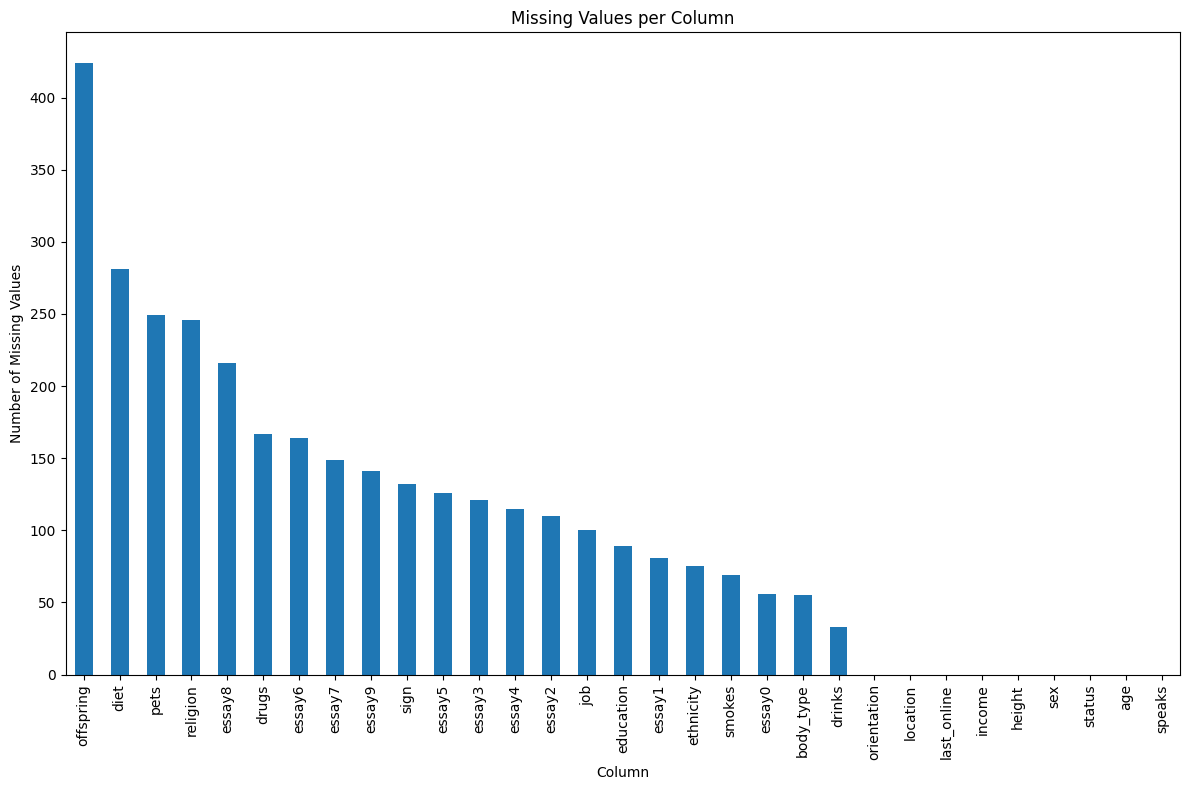

In [6]:
plt.figure(figsize=(12, 8))
missing_values.plot(kind="bar")
plt.title("Missing Values per Column")
plt.xlabel("Column")
plt.ylabel("Number of Missing Values")
plt.tight_layout()
plt.show()

## 4. Combine Essay Fields Into One Bio

OkCupid stores profile text across `essay0` to `essay9`. These fields are filled where missing and joined into one `full_bio` column so the NLP models can read each profile as one text sample.

In [7]:
essay_columns = [f"essay{i}" for i in range(10)]

df[essay_columns].head()

,essay0,essay1,essay2,essay3,essay4,essay5,essay6,essay7,essay8,essay9
0,i am really obsessed with music and would love...,i am supervisor and i am really bored of it. i...,guitar i like to think i am alright. i am alwa...,well used to be my hair. had to get rid of the...,to many movies to just pick one and same with ...,my brother my guitars my friends my phone my p...,NaN,trying to have fun in what ever is fun to do t...,NaN,want to be friends. to see whats up? or what e...
1,"as for me, im a crazy busy hair stylist by day...",trying to juggle career and life,NaN,i suppose you could ask them.,NaN,laughing....and laughing some more. my phone. ...,my plan to take over the world!,usually home...i have to work on sat,"i cry at movies, shows, and live entertainment...",ya wanna!
2,i like to look for the humorous side in everyt...,"currently going to business school full time, ...","writing, telling stories, laughing at myself, ...","people tell me i'm sarcastic, funny (hilarious...","movies: office space, fight club - i love situ...","friends to share inside jokes with, yosemite v...",how there are so many beautiful and strange pl...,"packing for a last minute camping trip, bbqing...",i was born in a car.,if you're adventurous and enjoy making new fri...
3,"i love trees, i'm not crazy about them though ...",12:50 press return if you know what that is yo...,"different things, different times. but general...","i look way too innocent, clueless or oblivious...","d-_-b tool, in flames, lately a lot of post-ro...",my head and right hand fingers,"everything. well, i don't really think - mostl...",there's no typical friday,i often enjoy chick flicks,and only if you identify strongly with this: h...
4,"i come to san francisco by way of new york, wh...",i've taken up iaido with a fantastic sensei in...,observing myself and others. sticking with it ...,"beats me! nobody has ever told me, and i've ne...",books: i've been on a non-fiction/history kick...,food & water. i pretty much need those to live...,why people can't be nicer to each other.,"hanging out with friends, playing guitar at ho...","large gatherings of people at parties, bars or...","you're a sincere, kind and strong person. you ..."


In [8]:
df[essay_columns].isnull().sum()

essay0     56
essay1     81
essay2    110
essay3    121
essay4    115
essay5    126
essay6    164
essay7    149
essay8    216
essay9    141
dtype: int64

In [9]:
df[essay_columns] = df[essay_columns].fillna("")

df["full_bio"] = df[essay_columns].agg(" ".join, axis=1)

df[["essay0", "essay1", "full_bio"]].head()

,essay0,essay1,full_bio
0,i am really obsessed with music and would love...,i am supervisor and i am really bored of it. i...,i am really obsessed with music and would love...
1,"as for me, im a crazy busy hair stylist by day...",trying to juggle career and life,"as for me, im a crazy busy hair stylist by day..."
2,i like to look for the humorous side in everyt...,"currently going to business school full time, ...",i like to look for the humorous side in everyt...
3,"i love trees, i'm not crazy about them though ...",12:50 press return if you know what that is yo...,"i love trees, i'm not crazy about them though ..."
4,"i come to san francisco by way of new york, wh...",i've taken up iaido with a fantastic sensei in...,"i come to san francisco by way of new york, wh..."


In [10]:
print(df["full_bio"].iloc[0][:1000])

i am really obsessed with music and would love to do something with it. my music idol is tom delonge. my friends always make fun of me because i buy anything he does. i am supervisor and i am really bored of it. i really need to get back into school. guitar i like to think i am alright. i am always trying to improve at it. well used to be my hair. had to get rid of the blonde mohawk. so now i would say my plugs. i usually get somekind of comment to my earrings. to many movies to just pick one and same with tv shows. but some of the best are scott pilgrim and the office. music is the best thing ever and i surround myself with it everyday. pizza is the best food i could eat it when ever. my brother my guitars my friends my phone my ps3 and oxygen obviously  trying to have fun in what ever is fun to do that night.  want to be friends. to see whats up? or what ever reason you can think of. lets talk


## 5. Clean the Bio Text

The cleaning function lowercases text, removes HTML, removes links, removes unusual characters, and normalizes spacing. This creates a simpler `clean_bio` field for weak labeling and later model training.

In [11]:
def clean_text(text):
    text = str(text).lower()
    
    # remove HTML tags
    text = re.sub(r"<.*?>", " ", text)
    
    # remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)
    
    # remove non-alphanumeric characters except apostrophes
    text = re.sub(r"[^a-zA-Z0-9\s']", " ", text)
    
    # normalize spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

In [12]:
df["clean_bio"] = df["full_bio"].apply(clean_text)

df[["full_bio", "clean_bio"]].head()

,full_bio,clean_bio
0,i am really obsessed with music and would love...,i am really obsessed with music and would love...
1,"as for me, im a crazy busy hair stylist by day...",as for me im a crazy busy hair stylist by day ...
2,i like to look for the humorous side in everyt...,i like to look for the humorous side in everyt...
3,"i love trees, i'm not crazy about them though ...",i love trees i'm not crazy about them though n...
4,"i come to san francisco by way of new york, wh...",i come to san francisco by way of new york whe...


## 6. Explore Bio Length

Bio length is used as a simple profile-effort signal. Very short bios can indicate incomplete profiles, and the distribution helps choose a reasonable threshold.

In [13]:
df["bio_length"] = df["clean_bio"].apply(lambda x: len(x.split()))

df["bio_length"].describe()

count     700.000000
mean      363.194286
std       272.806024
min         0.000000
25%       161.750000
50%       308.500000
75%       491.250000
max      1904.000000
Name: bio_length, dtype: float64

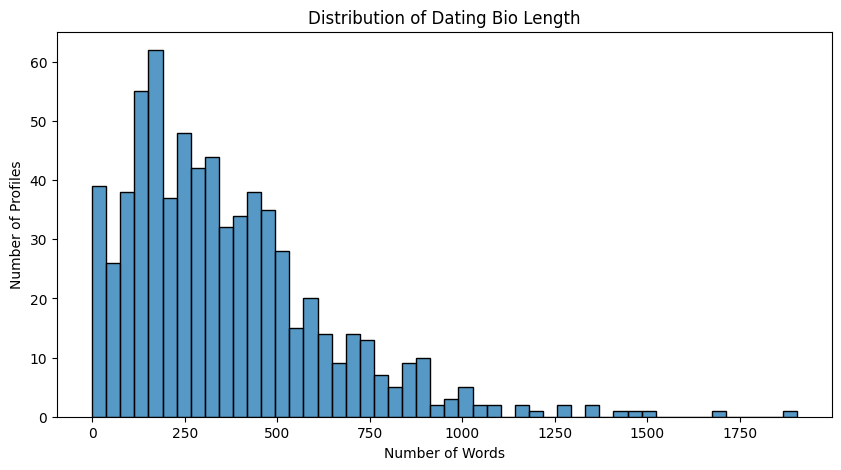

In [14]:
plt.figure(figsize=(10, 5))
sns.histplot(df["bio_length"], bins=50)
plt.title("Distribution of Dating Bio Length")
plt.xlabel("Number of Words")
plt.ylabel("Number of Profiles")
plt.show()

## 7. Define the Red-Flag Taxonomy

The taxonomy lists the labels used by the project, including text-only labels and labels that can also use tabular metadata. These labels become the multi-label targets for later notebooks.

In [15]:
red_flag_taxonomy = {
    "aggressive_tone": {
        "description": "Harsh, hostile, demanding, or insulting language.",
        "modality": "text"
    },
    "hookup_focus": {
        "description": "Strong focus on casual sexual encounters or non-committal intent.",
        "modality": "text"
    },
    "negativity": {
        "description": "Frequent pessimistic, cynical, bitter, or emotionally negative statements.",
        "modality": "text"
    },
    "sarcasm_cynicism": {
        "description": "Sarcastic, dismissive, or cynical tone that may affect interpretation.",
        "modality": "text"
    },
    "substance_risk": {
        "description": "Mentions of heavy drinking, drugs, smoking, or party-heavy lifestyle.",
        "modality": "text/tabular"
    },
    "incomplete_profile": {
        "description": "Low-effort or incomplete profile with very little useful information.",
        "modality": "text/tabular"
    },

    # Newer interpersonal toxicity labels
    "controlling_behavior": {
        "description": "Language suggesting control, obedience, punishment, dominance, or power over a partner.",
        "modality": "text"
    },
    "emotional_manipulation": {
        "description": "Silent treatment, guilt, emotional punishment, testing, conditional affection, or making others feel responsible for the user's feelings.",
        "modality": "text"
    },
    "entitlement_superiority": {
        "description": "Self-important, superior, arrogant, or 'people must impress me' framing.",
        "modality": "text"
    },
    "poor_conflict_resolution": {
        "description": "Cutting people off, refusing communication, revenge, blame-shifting, or inability to resolve conflict maturely.",
        "modality": "text"
    },
    "main_character_syndrome": {
        "description": "Self-centred profile framing where the person treats others as background characters, expects special attention, or presents themselves as uniquely important.",
        "modality": "text"
    },
    "dismissive": {
        "description": "Invalidating, belittling, contemptuous, or emotionally dismissive wording toward other people's feelings, interests, boundaries, or efforts.",
        "modality": "text"
    },

    # Visual labels
    "visual_filter_artifact": {
        "description": "Heavy filters, blur, face obstruction, suspicious editing, or visual presentation artifacts.",
        "modality": "image"
    },
    "multiple_face_confusion": {
        "description": "Profile image contains multiple faces, creating identity ambiguity.",
        "modality": "image"
    }
}

In [16]:
taxonomy_df = pd.DataFrame(red_flag_taxonomy).T
taxonomy_df

,description,modality
aggressive_tone,"Harsh, hostile, demanding, or insulting language.",text
hookup_focus,Strong focus on casual sexual encounters or no...,text
negativity,"Frequent pessimistic, cynical, bitter, or emot...",text
sarcasm_cynicism,"Sarcastic, dismissive, or cynical tone that ma...",text
substance_risk,"Mentions of heavy drinking, drugs, smoking, or...",text/tabular
incomplete_profile,Low-effort or incomplete profile with very lit...,text/tabular
controlling_behavior,"Language suggesting control, obedience, punish...",text
emotional_manipulation,"Silent treatment, guilt, emotional punishment,...",text
entitlement_superiority,"Self-important, superior, arrogant, or 'people...",text
poor_conflict_resolution,"Cutting people off, refusing communication, re...",text


## 8. Create Weak Labels With Keyword Rules

This first notebook does not manually label every profile. Instead, it uses transparent keyword rules and simple metadata rules to create weak labels that can bootstrap model training.

In [17]:
keyword_rules = {
    "aggressive_tone": [
        "don't message me", "do not message me", "don't waste my time",
        "idiot", "stupid", "hate people", "no drama", "must be",
        "if you are boring", "swipe left", "get lost", "shut up",
        "i don't tolerate", "i do not tolerate", "you better",
        "don't be annoying", "do not be annoying", "don't be dumb",
        "do not be dumb", "prove me wrong"
    ],

    "hookup_focus": [
        "hookup", "hook up", "one night", "one-night", "fwb",
        "friends with benefits", "casual sex", "nothing serious",
        "no strings attached", "just fun", "dtf", "come over",
        "not looking for commitment", "no commitment", "situationship",
        "late night fun", "sneaky link"
    ],

    "negativity": [
        "tired of", "sick of", "people suck", "i hate", "boring people",
        "done with", "waste of time", "miserable", "lonely",
        "everyone disappoints", "nobody understands", "dating is trash",
        "i have no faith", "what's the point", "life is boring",
        "most people are boring", "everyone is fake", "people are fake",
        "i don't trust people", "i do not trust people"
    ],

    "sarcasm_cynicism": [
        "obviously", "yeah right", "as if", "whatever",
        "good luck with that", "not impressed", "i guess", "sure jan",
        "wow amazing", "how original", "must be nice",
        "classic", "typical", "of course", "because apparently",
        "apparently", "congratulations", "great job"
    ],

    "substance_risk": [
        "drunk", "wasted", "party hard", "weed", "drugs", "high",
        "smoke every day", "drink every day", "stoned", "blackout",
        "black out", "vodka", "whiskey", "tequila", "shots",
        "club every weekend", "partying every weekend", "i drink a lot",
        "i smoke a lot", "420 friendly", "420"
    ],

    "incomplete_profile": [
        "just ask", "ask me", "idk", "i don't know", "i do not know",
        "nothing to say", "will fill later", "fill this later",
        "too lazy to write", "lazy to write", "message me to know",
        "find out yourself", "don't know what to write",
        "do not know what to write", "new here", "hi", "hello"
    ],

    "controlling_behavior": [
        "i am always right", "i'm always right", "im always right",
        "my way or the highway", "must obey", "you must obey",
        "listen to me", "do as i say", "i make the rules",
        "i decide", "i expect obedience", "obedient", "submissive",
        "i don't compromise", "i do not compromise",
        "i need to be in control", "i like being in control",
        "you need to learn", "they need to learn",
        "learn from their mistakes", "teach them a lesson",
        "i will teach you", "i will fix you"
    ],

    "emotional_manipulation": [
        "silent treatment", "test people", "testing people",
        "i test loyalty", "prove your loyalty", "make them feel guilty",
        "guilt trip", "conditional affection", "earn my affection",
        "earn my love", "i withdraw affection", "i ignore them",
        "ignore them until", "punish them", "emotional punishment",
        "if they cared they would know", "if you cared you would know",
        "make them learn", "make them regret", "i disappear when upset",
        "i go cold", "i shut people out"
    ],

    "entitlement_superiority": [
        "not like everyone else", "i'm not like everyone else",
        "im not like everyone else", "i am not like everyone else",
        "i deserve the best", "impress me", "people must impress me",
        "you need to impress me", "i have high standards",
        "most people are beneath me", "most people are boring",
        "i'm better than", "im better than", "i am better than",
        "i know my worth", "treat me like royalty",
        "queen treatment", "king treatment", "i should be worshipped",
        "worship me", "i am the prize", "i'm the prize", "im the prize"
    ],

    "poor_conflict_resolution": [
        "cut people off", "i cut people off", "cut them off",
        "keep distance", "i keep distance", "wronged me",
        "once they hurt my feelings", "hurt my feelings",
        "they are dead to me", "dead to me", "i don't forgive",
        "i do not forgive", "never forgive", "hold grudges",
        "i hold grudges", "revenge", "get even", "payback",
        "i don't talk things out", "i do not talk things out",
        "not worth discussing", "i shut down", "i walk away forever",
        "they don't deserve closure", "they do not deserve closure"
    ],

    "main_character_syndrome": [
        "main character", "main character energy", "main character vibes",
        "the world revolves around me", "everyone else is background",
        "background character", "side character", "i'm the protagonist",
        "im the protagonist", "i am the protagonist",
        "my story", "my era", "my villain era", "villain era",
        "people are lucky to know me", "lucky to have me",
        "i'm unforgettable", "im unforgettable", "i am unforgettable",
        "i'm iconic", "im iconic", "i am iconic",
        "born to stand out", "center of attention",
        "i deserve attention", "attention should be on me"
    ],

    "dismissive": [
        "too sensitive", "you're too sensitive", "you are too sensitive",
        "people are too sensitive", "overreacting", "stop overreacting",
        "not my problem", "i don't care", "i do not care",
        "whatever", "deal with it", "cry about it",
        "that's your problem", "that is your problem",
        "your feelings are not my problem", "not responsible for your feelings",
        "i don't do feelings", "i do not do feelings",
        "don't be dramatic", "do not be dramatic",
        "drama queen", "grow up", "get over it",
        "i hate clingy people", "clingy people are annoying"
    ]
}

In [18]:
def weak_label_text(text, keywords):
    text = str(text).lower()
    return int(any(keyword in text for keyword in keywords))

In [19]:
for label, keywords in keyword_rules.items():
    df[label] = df["clean_bio"].apply(lambda x: weak_label_text(x, keywords))

In [20]:
df["incomplete_profile"] = (df["bio_length"] < 20).astype(int)

In [21]:
df["tabular_substance_risk"] = (
    (df["drinks"].astype(str).str.contains("often|desperately", case=False, na=False)) |
    (df["drugs"].astype(str).str.contains("sometimes|often", case=False, na=False)) |
    (df["smokes"].astype(str).str.contains("yes|sometimes|trying to quit", case=False, na=False))
).astype(int)

In [22]:
df["substance_risk"] = (
    (df["substance_risk"] == 1) | 
    (df["tabular_substance_risk"] == 1)
).astype(int)

In [23]:
label_columns = [
    "aggressive_tone",
    "hookup_focus",
    "negativity",
    "sarcasm_cynicism",
    "substance_risk",
    "incomplete_profile",
    "controlling_behavior",
    "emotional_manipulation",
    "entitlement_superiority",
    "poor_conflict_resolution",
    "main_character_syndrome",
    "dismissive",
]

## 9. Check Label Imbalance

The positive count for each label shows how imbalanced the task is. This motivates later use of class-imbalance techniques such as SMOTE in the tabular notebook.

In [24]:
df[label_columns].sum().sort_values(ascending=False)

sarcasm_cynicism            303
substance_risk              289
dismissive                  102
aggressive_tone              61
negativity                   57
incomplete_profile           29
controlling_behavior         12
hookup_focus                 11
poor_conflict_resolution      7
main_character_syndrome       4
entitlement_superiority       3
emotional_manipulation        0
dtype: int64

In [25]:
label_distribution = pd.DataFrame({
    "positive_count": df[label_columns].sum(),
    "positive_percentage": df[label_columns].mean() * 100
}).sort_values("positive_count", ascending=False)

label_distribution

,positive_count,positive_percentage
sarcasm_cynicism,303,43.285714
substance_risk,289,41.285714
dismissive,102,14.571429
aggressive_tone,61,8.714286
negativity,57,8.142857
incomplete_profile,29,4.142857
controlling_behavior,12,1.714286
hookup_focus,11,1.571429
poor_conflict_resolution,7,1.000000
main_character_syndrome,4,0.571429


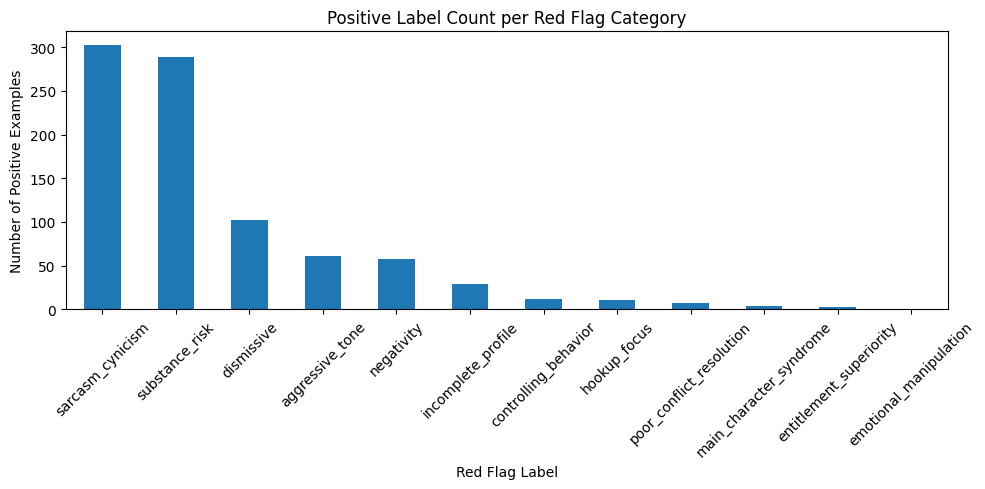

In [26]:
plt.figure(figsize=(10, 5))
label_distribution["positive_count"].plot(kind="bar")
plt.title("Positive Label Count per Red Flag Category")
plt.xlabel("Red Flag Label")
plt.ylabel("Number of Positive Examples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
df.columns.tolist()

['age',
 'status',
 'sex',
 'orientation',
 'body_type',
 'diet',
 'drinks',
 'drugs',
 'education',
 'ethnicity',
 'height',
 'income',
 'job',
 'last_online',
 'location',
 'offspring',
 'pets',
 'religion',
 'sign',
 'smokes',
 'speaks',
 'essay0',
 'essay1',
 'essay2',
 'essay3',
 'essay4',
 'essay5',
 'essay6',
 'essay7',
 'essay8',
 'essay9',
 'full_bio',
 'clean_bio',
 'bio_length',
 'aggressive_tone',
 'hookup_focus',
 'negativity',
 'sarcasm_cynicism',
 'substance_risk',
 'incomplete_profile',
 'controlling_behavior',
 'emotional_manipulation',
 'entitlement_superiority',
 'poor_conflict_resolution',
 'main_character_syndrome',
 'dismissive',
 'tabular_substance_risk']

## 10. Build the Cleaned Training Table

The final table keeps profile metadata, cleaned text fields, bio length, and all red-flag labels. This is the shared dataset used by the later NLP and tabular notebooks.

In [28]:
profile_columns = [
    "age",
    "status",
    "sex",
    "orientation",
    "body_type",
    "diet",
    "drinks",
    "drugs",
    "education",
    "ethnicity",
    "height",
    "income",
    "job",
    "last_online",
    "location",
    "offspring",
    "pets",
    "religion",
    "sign",
    "smokes",
    "speaks"
]

text_columns = [
    "full_bio",
    "clean_bio",
    "bio_length"
]

label_columns = [
    "aggressive_tone",
    "hookup_focus",
    "negativity",
    "sarcasm_cynicism",
    "substance_risk",
    "incomplete_profile",
    "controlling_behavior",
    "emotional_manipulation",
    "entitlement_superiority",
    "poor_conflict_resolution",
    "main_character_syndrome",
    "dismissive",
]

cleaned_df = df[profile_columns + text_columns + label_columns].copy()

cleaned_df.head()

,age,status,sex,orientation,body_type,diet,drinks,drugs,education,ethnicity,...,negativity,sarcasm_cynicism,substance_risk,incomplete_profile,controlling_behavior,emotional_manipulation,entitlement_superiority,poor_conflict_resolution,main_character_syndrome,dismissive
0,26,single,m,straight,average,anything,socially,never,graduated from high school,white,...,0,1,0,0,0,0,0,0,0,0
1,37,single,m,gay,athletic,NaN,socially,never,NaN,white,...,0,0,0,0,0,0,0,0,0,0
2,30,single,m,straight,fit,anything,socially,never,working on masters program,asian,...,0,1,0,0,0,0,0,0,0,0
3,26,single,m,straight,average,mostly anything,socially,NaN,graduated from college/university,"middle eastern, other",...,0,1,1,0,0,0,0,0,0,0
4,33,single,m,straight,average,strictly anything,often,NaN,graduated from college/university,white,...,1,1,1,0,0,0,0,0,0,1


## 11. Export the Cleaned Dataset

The cleaned dataset is saved as both CSV and pickle so later notebooks can load it without repeating the full exploration and weak-labeling process.

In [29]:
cleaned_df.to_csv("../data/okcupid_cleaned_redflags.csv", index=False)
cleaned_df.to_pickle("../data/okcupid_cleaned_redflags.pkl")
print("Cleaned dataset exported successfully.")
print("File path: data/processed/okcupid_cleaned_redflags.csv")

Cleaned dataset exported successfully.
File path: data/processed/okcupid_cleaned_redflags.csv


## Summary

Notebook 01 turns raw dating-profile data into a cleaned, weakly labeled dataset. The next notebooks use this exported dataset to train NLP models, handle tabular imbalance with SMOTE, evaluate YOLO visual signals, and build the final interactive auditing agent.